# jeanie: gradients, ensembles and existence

Five things an inference run needs, and the reduced solver's answer to each.

`jeanie`'s JAX path differentiates the solve by the implicit function theorem,
so a gradient costs about as much as a solve rather than 12 finite-difference
solves. It also answers *whether a solution exists at all*, which matters more
than it sounds: the matching problem is multi-valued, and roughly 7% of a
plausible prior has no solution.

| § | What it shows | Why it matters for inference |
|:--|:--|:--|
| **1** | the full $2\times6$ Jacobian in one pass | gradient-based samplers, and which parameters actually move the core |
| **2** | those gradients are exact, not differenced | no step size to tune, no round-off floor |
| **3** | 64 halos in one batched call | the per-halo cost falls by about $10\times$ |
| **4** | an exact existence criterion | a root is not an answer until something says which branch it is on |
| **5** | the potential in closed form | an acceleration, called millions of times per likelihood |

Every section states its conclusion first, in bold, then shows the work.

Companion notebook: **`jeanie_basics.ipynb`**, which checks the solve against
`jeans` itself and covers exporting to galpy, agama and galax.

## Setup

The same Milky-Way-like host throughout: a $10^{12}\,M_\odot$ NFW halo with a
Miyamoto–Nagai disc, matched at $r_1 = 12$ kpc. Here the parameters are one
vector, `p = (M200, c, r1, Md, a, b)`, because that is what gets
differentiated.

In [1]:
import time

import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)   # 32-bit will not resolve a 1e-10 residual

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from jeanie.jaxsolver import solve_log, nfw_boundary

NAMES = ["M200", "c", "r1", "Md", "a", "b"]

#             M200    c     r1     Md     a     b
p = jnp.array([1e12, 10.0, 12.0, 6e10, 3.0, 0.28])

lg = solve_log(p)
print(f"r0     = {float(jnp.exp(lg[0])):.6f} kpc")
print(f"sigma0 = {float(jnp.exp(lg[1])):.4f} km/s")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


r0     = 1.750607 kpc
sigma0 = 156.5550 km/s


## 1. The Jacobian, in one pass

**`jacfwd` returns the whole $2\times6$ derivative matrix for about the cost of
one solve.**

Logarithmic derivatives are the readable form: how far does the core radius
move per *fractional* change in each parameter? They are dimensionless, so the
six entries are directly comparable.

In [2]:
jac = np.asarray(jax.jacfwd(solve_log)(p))          # d log(r0, sigma0) / d p

logderiv = pd.DataFrame(
    {"dlog r0 / dlog x": jac[0] * np.asarray(p),
     "dlog sigma0 / dlog x": jac[1] * np.asarray(p)},
    index=NAMES,
).round(4)
logderiv

,dlog r0 / dlog x,dlog sigma0 / dlog x
M200,0.1382,0.1348
c,-0.4804,0.1088
r1,-0.3577,-0.0688
Md,0.0269,0.2901
a,0.7425,-0.1982
b,0.1199,-0.0077


## 2. Gradients are exact, not differenced

**The agreement with finite differences plateaus over several decades of step
size — which is what tells you the autodiff value is the exact one.**

The comparison is against central differences of the *numba* solver, a separate
implementation of the same equations, so this checks the two paths against each
other as well as the derivative.

A finite-difference gradient has no such plateau: it is dominated by truncation
error at large steps and by round-off at small ones, with a single sweet spot
in between that has to be found per-parameter.

In [3]:
from jeanie.solver import solve_spherical

GN = 4.302e-6


def numba_log_r0(q):
    """log r0 from the independent numba solver, for finite differencing."""
    M200, c, r1, Md, a, b = [float(v) for v in q]
    rho1, M1 = [float(v) for v in nfw_boundary(M200, c, r1)]
    pb = lambda r, th: -GN * Md / np.sqrt(
        r ** 2 * np.sin(th) ** 2
        + (a + np.sqrt(b ** 2 + r ** 2 * np.cos(th) ** 2)) ** 2)
    return np.log(solve_spherical(r1, rho1, M1, Phi_b=pb).r0)


k = NAMES.index("c")                      # differentiate with respect to concentration
exact = float(jac[0, k])

steps = np.logspace(-2, -8, 13)
errs = []
for s in steps:
    d = np.zeros(6)
    d[k] = s * float(p[k])
    fd = (numba_log_r0(np.asarray(p) + d)
          - numba_log_r0(np.asarray(p) - d)) / (2 * d[k])
    errs.append(abs(fd / exact - 1.0))
errs = np.array(errs)

best agreement: 2.44e-11  (at step 1e-05)


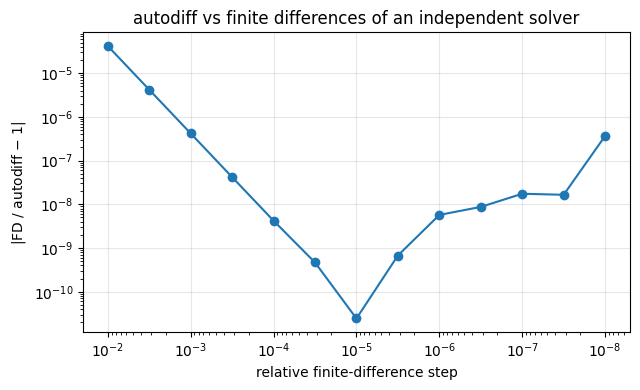

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.loglog(steps, errs, "o-", c="C0")
ax.invert_xaxis()
ax.set(xlabel="relative finite-difference step",
       ylabel=r"|FD / autodiff $-$ 1|",
       title="autodiff vs finite differences of an independent solver")
ax.grid(alpha=0.3)
fig.tight_layout()

print(f"best agreement: {errs.min():.2e}  (at step {steps[errs.argmin()]:.0e})")

## 3. A whole ensemble at once

**`vmap` turns the solve into a batched kernel, and the per-halo cost falls by
about an order of magnitude.**

This is what makes a sampler affordable — a likelihood evaluation over a
population of halos becomes one call rather than a Python loop. The exact
factor depends on the machine and the batch size, so it is measured below
rather than quoted.

In [5]:
P = jnp.tile(p, (64, 1)).at[:, 0].set(jnp.linspace(4e11, 3e12, 64))

single = jax.jit(solve_log)
batched = jax.jit(jax.vmap(solve_log))
single(p).block_until_ready()                        # compile both, then time
batched(P).block_until_ready()

t0 = time.perf_counter()
for row in P[:16]:
    single(row).block_until_ready()
t_loop = (time.perf_counter() - t0) / 16

t0 = time.perf_counter()
batched(P).block_until_ready()
t_batch = (time.perf_counter() - t0) / len(P)

print(f"per halo: {t_loop * 1e3:5.1f} ms looped")
print(f"          {t_batch * 1e3:5.1f} ms batched   ({t_loop / t_batch:.0f}x)")

r0s = np.exp(np.asarray(batched(P))[:, 0])

per halo:  55.6 ms looped
            4.9 ms batched   (11x)


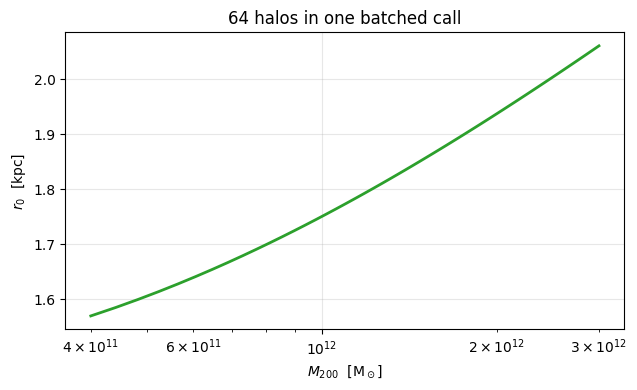

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogx(np.asarray(P)[:, 0], r0s, c="C2", lw=2)
ax.set(xlabel=r"$M_{200}$  [M$_\odot$]", ylabel=r"$r_0$  [kpc]",
       title="64 halos in one batched call")
ax.grid(alpha=0.3)
fig.tight_layout()

## 4. Does a solution exist?

**Beyond $R_{\rm MAX} = 1.2615$ there is no solution, and `jeanie` says so
rather than returning something plausible.**

The matching problem is the classical isothermal spiral. The matching ratio

$$R = \frac{M_1}{4\pi r_1^3 \rho_1}$$

turns over at $R_{\rm MAX}$, so past that point nothing satisfies the
equations. Between $r_1/r_s = 1.78$ and $3.97$ a solution exists but is **not
unique**, and picking the wrong branch gives an answer that satisfies the
equations to $10^{-15}$ while being wrong by orders of magnitude.

`jeanie` solves by bracketing, which cannot reach another branch.

In [7]:
from jeanie import universal
from jeanie.outer import boundary_data
from jeans.classes import CDM_profile

Md, a_d, b_d = 6e10, 3.0, 0.28


def Phi_b(r, th):
    R2 = r ** 2 * np.sin(th) ** 2
    zb = a_d + np.sqrt(b_d ** 2 + r ** 2 * np.cos(th) ** 2)
    return -GN * Md / np.sqrt(R2 + zb ** 2)


halo = CDM_profile(1e12, 10.0, q0=1.0, Phi_b=Phi_b)

r1s = np.linspace(4.0, 70.0, 40)
ratio, solved = [], []
for x in r1s:
    rho1, M1, _ = boundary_data(halo, float(x), L_list=(0,))
    ratio.append(universal.matching_ratio_of(float(x), rho1, M1))
    solved.append(solve_spherical(float(x), rho1, M1, Phi_b=Phi_b).success)
ratio, solved = np.array(ratio), np.array(solved)

solvable for 16 of 40 matching radii tried


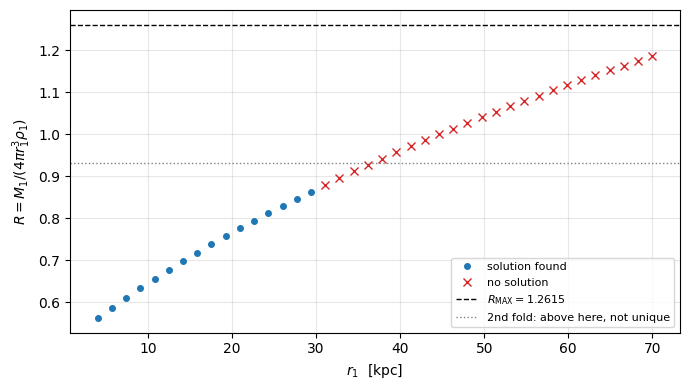

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r1s[solved], ratio[solved], "o", ms=4, c="C0", label="solution found")
ax.plot(r1s[~solved], ratio[~solved], "x", ms=6, c="C3", label="no solution")
ax.axhline(universal.R_MAX, ls="--", c="k", lw=1,
           label=r"$R_{\rm MAX} = 1.2615$")
ax.axhline(0.932, ls=":", c="grey", lw=1,
           label="2nd fold: above here, not unique")
ax.set(xlabel=r"$r_1$  [kpc]",
       ylabel=r"$R = M_1 / (4\pi r_1^3 \rho_1)$")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()

print(f"solvable for {solved.sum()} of {len(solved)} matching radii tried")

## 5. The potential, in closed form

**There is no Poisson solve to differentiate: the march's second variable *is*
the enclosed mass, so $M(<r)$ and $g_r(r)$ come straight out of the
solution.**

What a stream integrator needs is an acceleration, called millions of times per
likelihood. Continuity at $r_1$ is a matching condition rather than something
imposed afterwards, so it holds to machine precision.

In [9]:
from jeanie import jaxprofile as JP

M = JP.mass_fn(p)
g = JP.radial_acceleration_fn(p)
rho = JP.density_fn(p)

r1v = float(p[2])
M1 = float(nfw_boundary(float(p[0]), float(p[1]), r1v)[1])
print(f"M(<r1)/M1 - 1 = {abs(float(M(r1v)) / M1 - 1):.2e}   (exact by construction)")

M(<r1)/M1 - 1 = 2.66e-15   (exact by construction)


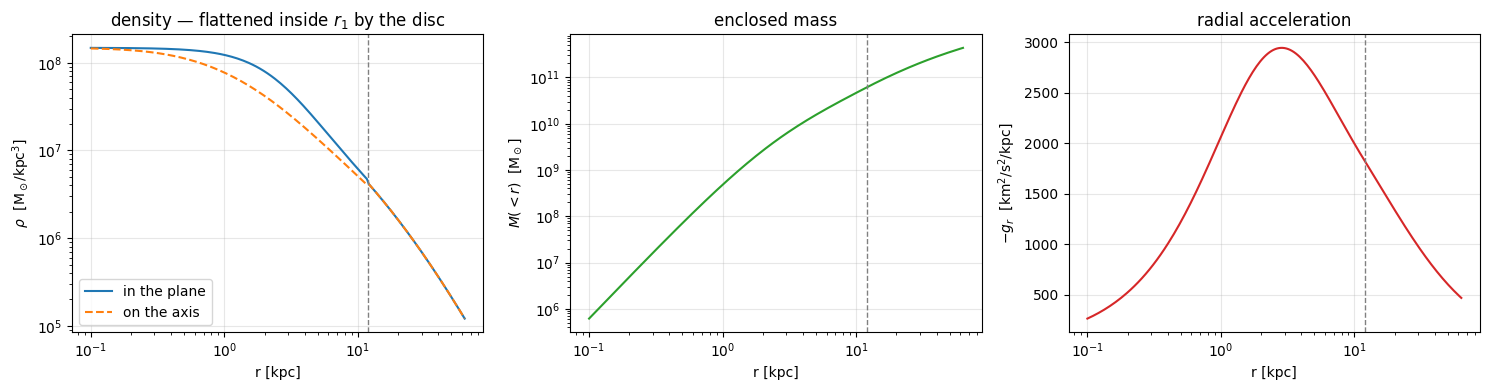

In [10]:
rr = np.logspace(-1, 1.8, 200)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].loglog(rr, [float(rho(x, 0.0)) for x in rr], c="C0", label="in the plane")
axs[0].loglog(rr, [float(rho(0.0, x)) for x in rr], c="C1", ls="--", label="on the axis")
axs[0].set(ylabel=r"$\rho$  [M$_\odot$/kpc$^3$]",
           title=r"density — flattened inside $r_1$ by the disc")
axs[0].legend()

axs[1].loglog(rr, [float(M(x)) for x in rr], c="C2")
axs[1].set(ylabel=r"$M(<r)$  [M$_\odot$]", title="enclosed mass")

axs[2].semilogx(rr, [-float(g(x)) for x in rr], c="C3")
axs[2].set(ylabel=r"$-g_r$  [km$^2$/s$^2$/kpc]", title="radial acceleration")

for ax in axs:
    ax.axvline(r1v, ls="--", c="grey", lw=1)
    ax.set_xlabel("r [kpc]")
    ax.grid(alpha=0.3)
fig.tight_layout()

The dashed line is $r_1$. In the left panel the two curves separate inside it,
because the dark matter feels the disc there, and meet outside it, because this
host has $q_0 = 1$. Across $r_1$ itself nothing discontinuous happens in $M$ or
$g_r$ — which is the point.

And because all of it is JAX, the acceleration differentiates in the halo
parameters too:

In [11]:
dg = jax.grad(lambda q: JP.radial_acceleration_fn(q)(8.0))(p)

pd.DataFrame({"dg(8 kpc) / dlog x": [f"{float(v) * float(x):+12.3f}"
                                     for v, x in zip(dg, p)]},
             index=NAMES)

,dg(8 kpc) / dlog x
M200,-980.301
c,-2338.006
r1,-249.790
Md,-60.246
a,+124.637
b,+6.855


## What to take away

1. One `jacfwd` call gives the full parameter Jacobian, at about the cost of a
   solve — not 12 solves.
2. Those derivatives are exact, with no step size to tune; the plateau against
   an independent solver is the evidence.
3. `vmap` makes a population of halos one batched call.
4. The existence criterion is exact, so a sampler can reject rather than
   wander onto the wrong branch.
5. The exported acceleration is closed-form and differentiable.

**Next:** `jeanie_export_potentials.ipynb`, for handing this potential to
galpy, agama or galax — and what each of them costs in accuracy.